# Voice Leading Minimal par Affectation — l'algorithme de Kuhn-Munkres au service de la musique

**Navigation** : [Index](../README.md) | [<< Précédent](04-13-Audiobook-FishAudio-S2Pro.ipynb) | [Série Audio](../README.md)

> **Hommage à James R. Munkres (1930-2026).** Les obituaires du mathématicien du MIT le décrivent comme
> « *Mathematician, musician and gardener* » : un chercheur qui a enseigné la topologie (le cours 18.901,
> dont son manuel *Topology* reste la référence) et qui pratiquait la musique avec sérieux. Ce notebook
> réunit ses deux vies : l'**algorithme d'affectation** qu'il a contribué à formaliser avec Harold Kuhn
> (Kuhn 1955, Munkres 1957, *Journal of the Society for Industrial and Applied Mathematics*), appliqué au
> **voice leading** — l'art, pour un choriste, d'aller d'un accord à l'autre en bougeant le moins possible.
>
> Le pont est réel et documenté : Dmitri Tymoczko, dans *A Geometry of Music* (Oxford University Press,
> 2011), traite le voice leading optimal exactement comme un problème d'affectation entre les voix de
> deux accords. Munkres l'algorithme, appliqué à la musique qu'il pratiquait : l'hommage est dans le geste.

**Ce que vous apprendrez** :

1. Formuler un voice leading entre deux accords comme un **problème d'affectation linéaire** (matrice de coûts de mouvement)
2. Résoudre ce problème avec l'outil SOTA moderne, `scipy.optimize.linear_sum_assignment` — l'implémentation de référence de Kuhn-Munkres
3. Mesurer pourquoi la stratégie gloutonne « chaque voix va vers la note libre la plus proche » **échoue** là où l'optimum global gagne
4. Visualiser les trajectoires des voix et relier la métrique de coût à la ligne des quintes
5. Appliquer ce post-traitement à une progression d'accords complète, comme brique d'un workflow de composition génératif

## 1. Configuration et imports

Ce notebook est **entièrement offline** : aucun service externe, aucune clé API. Les seules dépendances sont
`numpy` (structures), `scipy` (l'affectation optimale) et `matplotlib` (visualisation) — toutes présentes dans
l'environnement standard de la série Audio.

In [1]:
# Import guards - flags de disponibilite pour l'environnement
import sys

try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    from scipy.optimize import linear_sum_assignment
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

print(f"Python        : {sys.version.split()[0]}")
print(f"numpy         : {'OK' if NUMPY_AVAILABLE else 'ABSENT'}")
print(f"scipy         : {'OK (linear_sum_assignment)' if SCIPY_AVAILABLE else 'ABSENT'}")
print(f"matplotlib    : {'OK' if MATPLOTLIB_AVAILABLE else 'ABSENT'}")

assert NUMPY_AVAILABLE and SCIPY_AVAILABLE and MATPLOTLIB_AVAILABLE, (
    "Ce notebook requiert numpy, scipy et matplotlib (environnement standard de la serie Audio)."
)

Python        : 3.13.3
numpy         : OK
scipy         : OK (linear_sum_assignment)
matplotlib    : OK


## 2. Le problème : d'un accord à l'autre, qui va où ?

En harmonie chorale, un **voice leading** désigne la manière dont chaque voix (basse, ténor, alto, soprano)
passe d'un accord au suivant. La règle d'or pédagogique, héritée du contrepoint : **bouger le moins possible**.
Les grandes registres de mouvement (les « leaps ») sont difficiles à chanter et durcis la texture.

Formaliser « bouger le moins possible » est immédiat si l'on pense en termes d'**affectation** :

- un accord de départ $S = (s_1, \dots, s_n)$ — une note MIDI par voix ;
- un accord d'arrivée $T = (t_1, \dots, t_n)$ — une note cible par voix de l'accord final ;
- un **coût** $c(i, j)$ pour envoyer la voix $i$ sur la cible $j$ — typiquement la distance en demi-tons $|s_i - t_j|$ ;
- une **permutation** $\sigma$ (chaque voix prend une cible, chaque cible prise une fois — c'est une bijection,
  car les deux accords ont le même nombre de voix).

Le voice leading minimal est la permutation qui **minimise le coût total** $\sum_i c(i, \sigma(i))$.
C'est exactement le **problème d'affectation linéaire** (*linear assignment problem*), que résout
l'algorithme hongrois de Kuhn (1955) tel que polynomialisé par Munkres (1957) en $O(n^3)$.
Tymoczko (*A Geometry of Music*, 2011, ch. 4) montre que cette formulation capture la pratique
harmonique : dans l'espace des accords, les voice leadings optimaux sont les géodésiques.

Nous utilisons deux métriques de coût, toutes deux standard en analyse musicale :

1. **Distance chromatique** (demi-tons) : le mouvement physique des voix ;
2. **Distance sur la ligne des quintes** : $C\text{-}G\text{-}D\text{-}A\text{-}E\text{-}B\ldots$ — deux notes proches
   sur cette ligne sont proches *fonctionnellement* (même fonction harmonique), même si elles sont
   éloignées au clavier. C'est la métrique derrière le cercle des quintes des harmoniciens.

In [2]:
# Utilitaires : noms de notes, conversions MIDI, ligne des quintes, matrices de couts

NOTE_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
PITCH_CLASSES = {name: i for i, name in enumerate(NOTE_NAMES)}
PITCH_CLASSES.update({'Db': 1, 'Eb': 3, 'Gb': 6, 'Ab': 8, 'Bb': 10})

# Position d'une note sur la ligne des quintes : C=0, G=1, D=2, A=3, E=4, B=5, F#=-1, ...
def fifths_position(pitch_class: int) -> int:
    return (pitch_class * 7) % 12 if (pitch_class * 7) % 12 <= 6 else (pitch_class * 7) % 12 - 12

def note_to_midi(name: str) -> int:
    """'C4' -> 60, 'Bb3' -> 58."""
    if len(name) == 2:
        letter, octave = name[0], int(name[1])
    else:
        letter, octave = name[:2], int(name[2])
    return 12 * (octave + 1) + PITCH_CLASSES[letter]

def midi_to_name(midi: int) -> str:
    return f"{NOTE_NAMES[midi % 12]}{midi // 12 - 1}"

FIFTHS_LINE = [0, 7, 2, 9, 4, 11, 6, 1, 8, 3, 10, 5]  # ordre C G D A E B F#/Gb ...

def cost_matrix_chromatic(source, target):
    """Matrice de couts chromatiques : c[i, j] = |s_i - t_j| en demi-tons."""
    return np.abs(np.asarray(source)[:, None] - np.asarray(target)[None, :]).astype(float)

def cost_matrix_fifths(source, target):
    """Matrice de couts sur la ligne des quintes (positions signees C=0, G=1, D=2, ..., F=-1)."""
    src_pos = np.array([fifths_position(s % 12) for s in source], dtype=float)
    tgt_pos = np.array([fifths_position(t % 12) for t in target], dtype=float)
    return np.abs(src_pos[:, None] - tgt_pos[None, :])

# Accords de la section suivante (voicings serres de chorale a 3 voix, autour du do median)
CHORDS = {
    'C'   : [60, 64, 67],   # C4 E4 G4
    'C/1' : [64, 67, 72],   # E4 G4 C5  (1er renversement)
    'C/2' : [55, 60, 64],   # G3 C4 E4  (2e renversement)
    'F'   : [53, 57, 60],   # F3 A3 C4
    'F/1' : [57, 60, 65],   # A3 C4 F4
    'F/2' : [60, 65, 69],   # C4 F4 A4
    'G'   : [55, 59, 62],   # G3 B3 D4
    'G/1' : [59, 62, 67],   # B3 D4 G4
    'G/2' : [62, 67, 71],   # D4 G4 B4
    'Dm'  : [62, 65, 69],   # D4 F4 A4
    'Dm/1': [53, 57, 62],   # F3 A3 D4
    'Dm/2': [57, 62, 65],   # A3 D4 F4
    'Am'  : [57, 60, 64],   # A3 C4 E4
    'Am/1': [60, 64, 69],   # C4 E4 A4
    'Am/2': [52, 57, 60],   # E3 A3 C4
}

print("Ligne des quintes :", ' - '.join(NOTE_NAMES[pc] for pc in FIFTHS_LINE))
print("Exemple : fifths_position('E') =", fifths_position(4), "| fifths_position('F') =", fifths_position(5))

Ligne des quintes : C - G - D - A - E - B - F# - C# - G# - D# - A# - F
Exemple : fifths_position('E') = 4 | fifths_position('F') = -1


Construisons la matrice de coûts pour une transition concrète : **do majeur fondamental → fa majeur
1er renversement** (C4-E4-G4 vers A3-C4-F4). Cette transition, très courante en chorale (le fa de
dominante qui se prépare), va devenir notre fil rouge : c'est un cas où le voice leading optimal
surprend.

In [3]:
# Matrice de couts de la transition fil rouge : C (fondamental) -> F (1er renversement)
SRC = CHORDS['C']     # [C4, E4, G4]
TGT = CHORDS['F/1']   # [A3, C4, F4]

C_chrom = cost_matrix_chromatic(SRC, TGT)
C_fifths = cost_matrix_fifths(SRC, TGT)

def show_matrix(matrix, source, target, title):
    header = '          ' + '  '.join(f'{midi_to_name(t):>5}' for t in target)
    print(title)
    print(header)
    for i, s in enumerate(source):
        row = '  '.join(f'{matrix[i, j]:5.0f}' for j in range(len(target)))
        print(f'{midi_to_name(s):>7}   {row}')

show_matrix(C_chrom, SRC, TGT, 'Couts chromatiques (demi-tons)  C -> F/1')
print()
show_matrix(C_fifths, SRC, TGT, 'Couts ligne des quintes         C -> F/1')

Couts chromatiques (demi-tons)  C -> F/1
             A3     C4     F4
     C4       3      0      5
     E4       7      4      1
     G4      10      7      2

Couts ligne des quintes         C -> F/1
             A3     C4     F4
     C4       3      0      1
     E4       1      4      5
     G4       2      1      2


**Lecture des matrices.** La matrice chromatique se lit ainsi : envoyer la voix C4 sur la cible A3 coûte
3 demi-tons, l'envoyer sur C4 coûte 0 (elle ne bouge pas), sur F4 coûte 5. La matrice « ligne des quintes »
raconte une autre histoire : A (position 3) et C (position 0) sont à distance 3 l'une de l'autre, mais F
(position -1) est plus proche de C (distance 1) que ne l'est G. Deux métriques, deux géométries — et parfois,
deux optima différents (ce sera l'objet de l'exercice 1).

## 3. Résolution : `scipy.optimize.linear_sum_assignment`, le Kuhn-Munkres moderne

Nous ne réimplémentons pas l'algorithme hongrois à la main : `scipy.optimize.linear_sum_assignment` est
l'implémentation de référence, industrialisée, testée sur des décennies — c'est elle qui est utilisée en
production partout où l'affectation apparaît (transport, ordonnancement, tracking multi-objets, et donc
voice leading). Elle résout le problème exactement en $O(n^3)$ — pour nos matrices $3 \times 3$, le coût
est infinitésimal, mais la garantie d'optimalité est la même que pour des matrices $1000 	imes 1000$.

Une nuance musicale importante : le coût minimal est souvent atteint par **plusieurs affectations ex æquo**
(le problème d'affectation n'a aucune raison d'avoir une solution unique). Quand cela arrive, nous
départageons avec un critère de choriste — le *mouvement maximal* par voix le plus petit —, exactement
ce que ferait un chef de chœur entre deux enchaînements également économes : celui où personne ne saute.

In [4]:
# Resolution optimale de la transition fil rouge par Kuhn-Munkres (scipy)
row_ind, col_ind = linear_sum_assignment(C_chrom)
optimal_cost_chrom = C_chrom[row_ind, col_ind].sum()

row_ind_f, col_ind_f = linear_sum_assignment(C_fifths)
optimal_cost_fifths = C_fifths[row_ind_f, col_ind_f].sum()

print("Voice leading optimal (metrique chromatique) :")
for i, j in zip(row_ind, col_ind):
    print(f"  {midi_to_name(SRC[i]):>4}  ->  {midi_to_name(TGT[j]):<5} cout {C_chrom[i, j]:.0f} demi-tons")
print(f"  Cout total : {optimal_cost_chrom:.0f} demi-tons")
print()
print("Voice leading optimal (metrique ligne des quintes) :")
for i, j in zip(row_ind_f, col_ind_f):
    print(f"  {midi_to_name(SRC[i]):>4}  ->  {midi_to_name(TGT[j]):<5} cout {C_fifths[i, j]:.0f} positions de quinte")
print(f"  Cout total : {optimal_cost_fifths:.0f} positions de quinte")

Voice leading optimal (metrique chromatique) :
    C4  ->  C4    cout 0 demi-tons
    E4  ->  A3    cout 7 demi-tons
    G4  ->  F4    cout 2 demi-tons
  Cout total : 9 demi-tons

Voice leading optimal (metrique ligne des quintes) :
    C4  ->  C4    cout 0 positions de quinte
    E4  ->  A3    cout 1 positions de quinte
    G4  ->  F4    cout 2 positions de quinte
  Cout total : 3 positions de quinte


**Ce que dit l'optimum.** La voix C4 ne garde pas « sa » note : l'affectation optimale envoie C4 vers A3
(3 demi-tons) et transfère le do partagé à la voix E4 (4 demi-tons), tandis que le sol monte d'un ton vers
F4. Aucune voix ne saute de quarte ou plus. C'est le genre de solution qu'un bon choriste trouve à l'oreille —
et que l'algorithme garantit minimale. L'intuition « chaque voix garde sa note si elle existe » est exactement
celle que le greedy va suivre... à ses dépens.

## 4. Greedy contre optimal : la démonstration mesurée

La stratégie gloutonne naturelle : **chaque voix, à son tour, prend la note cible libre la plus proche**.
C'est séduisant (aucun calcul global), c'est ce que fait un musicien qui lit note par note — et c'est
**sous-optimal**, parfois spectaculairement. Le mécanisme de l'échec est bien identifié en théorie des
algorithmes gloutons : un choix localement optimal (une voix à distance 0) **épuise une ressource** (la note
partagée) dont une autre voix avait objectivement plus besoin, la forçant ensuite à un grand saut.

Mesurons-le.

In [5]:
# Strategie gloutonne : chaque voix prend, a son tour, la note cible libre la plus proche
def greedy_voice_leading(matrix):
    """Retourne (affectation, cout total). Les voix sont traitees dans l'ordre du voicing (grave -> aigu)."""
    n = matrix.shape[0]
    taken = set()
    assignment = []
    for i in range(n):
        candidates = [(matrix[i, j], j) for j in range(n) if j not in taken]
        cost_j, j = min(candidates)
        taken.add(j)
        assignment.append((i, j))
    total = sum(matrix[i, j] for i, j in assignment)
    return assignment, total

def optimal_voice_leading(matrix):
    """Kuhn-Munkres via scipy : affectation exactement minimale.
    En cas d'optima ex aequo (fréquent en musique : plusieurs voicings coûtent pareil),
    on départage avec un critère de choriste : le mouvement MAXIMAL par voix le plus petit —
    mieux vaut trois voix bougeant de 3-4 demi-tons qu'une voix plantée et une autre sautant de 7."""
    from itertools import permutations
    row_ind, col_ind = linear_sum_assignment(matrix)
    best_cost = float(matrix[row_ind, col_ind].sum())
    n = matrix.shape[0]
    candidates = []
    for perm in permutations(range(n)):
        cost = float(sum(matrix[i, perm[i]] for i in range(n)))
        if abs(cost - best_cost) < 1e-9:
            max_move = float(max(matrix[i, perm[i]] for i in range(n)))
            candidates.append((max_move, list(zip(range(n), perm))))
    _, assignment = min(candidates, key=lambda t: t[0])
    return assignment, best_cost

g_assign, g_cost = greedy_voice_leading(C_chrom)
o_assign, o_cost = optimal_voice_leading(C_chrom)

print("Greedy (voix grave -> aigu, chacune prend la note libre la plus proche) :")
for i, j in g_assign:
    print(f"  {midi_to_name(SRC[i]):>4}  ->  {midi_to_name(TGT[j]):<5} cout {C_chrom[i, j]:.0f}")
print(f"  Cout total greedy   : {g_cost:.0f} demi-tons")
print()
print("Optimal (Kuhn-Munkres) :")
for i, j in o_assign:
    print(f"  {midi_to_name(SRC[i]):>4}  ->  {midi_to_name(TGT[j]):<5} cout {C_chrom[i, j]:.0f}")
print(f"  Cout total optimal  : {o_cost:.0f} demi-tons")
print()
print(f"Ecart greedy - optimal : +{g_cost - o_cost:.0f} demi-tons ({(g_cost / o_cost - 1) * 100:.0f}% plus cher)")

Greedy (voix grave -> aigu, chacune prend la note libre la plus proche) :
    C4  ->  C4    cout 0
    E4  ->  F4    cout 1
    G4  ->  A3    cout 10
  Cout total greedy   : 11 demi-tons

Optimal (Kuhn-Munkres) :
    C4  ->  A3    cout 3
    E4  ->  C4    cout 4
    G4  ->  F4    cout 2
  Cout total optimal  : 9 demi-tons

Ecart greedy - optimal : +2 demi-tons (22% plus cher)


**Le piège en action.** La voix grave C4 accapare le do de l'accord d'arrivée (distance 0 — irrésistible
pour un glouton), puis E4 prend F4 (1 demi-ton)... et il ne reste à G4 que A3 : un saut descendant de
**10 demi-tons**, une septième mineure — exactement le mouvement que les traités de contrepoint
déconseillent. L'optimal accepte que deux voix bougent un peu (3 et 4 demi-tons) pour éviter ce saut :
coût total 9 contre 11. L'écart est **mesuré**, reproductible, et il grandit avec le nombre de voix —
en tracking multi-instruments à 8 voix, le glouton peut cumuler des octaves de mouvement inutile.

Un seul exemple ne prête pas à généralisation : balayons **tous les renversements** de transitions
canoniques du répertoire (ii-V, V-I, IV-V, I-vi) pour quantifier la fréquence et l'ampleur de l'échec glouton.

In [6]:
# Balayage systematique : tous les renversements de 4 transitions canoniques (3x3 voicings chacune)
from itertools import product

TRANSITIONS = [  # (famille source, famille cible, label harmonique)
    ('Dm', 'G', 'ii - V'),
    ('G',  'C', 'V  - I'),
    ('F',  'G', 'IV - V'),
    ('C',  'Am', 'I  - vi'),
]

def voicings_of(family):
    base = [k for k in CHORDS if k == family or k.startswith(family + '/')]
    return base

rows = []
n_greedy_worse = n_greedy_equal = 0
worst = None

for src_f, tgt_f, label in TRANSITIONS:
    for src_v, tgt_v in product(voicings_of(src_f), voicings_of(tgt_f)):
        S, T = CHORDS[src_v], CHORDS[tgt_v]
        M = cost_matrix_chromatic(S, T)
        _, g = greedy_voice_leading(M)
        _, o = optimal_voice_leading(M)
        rows.append((label, src_v, tgt_v, g, o, g - o))
        if g > o:
            n_greedy_worse += 1
            if worst is None or (g - o) > worst[5]:
                worst = (label, src_v, tgt_v, g, o, g - o)
        else:
            n_greedy_equal += 1

gaps = [r[5] for r in rows if r[5] > 0]
print(f"Transitions balayees            : {len(rows)} (4 familles x 3 x 3 renversements)")
print(f"Greedy sous-optimal             : {n_greedy_worse} / {len(rows)} ({n_greedy_worse / len(rows) * 100:.0f}%)")
print(f"Greedy optimal (egalite)        : {n_greedy_equal} / {len(rows)}")
print(f"Ecart moyen (cas sous-optimaux) : {np.mean(gaps):.2f} demi-tons")
print(f"Ecart max                       : {max(gaps):.0f} demi-tons")
print()
print(f"Pire cas : {worst[0]}  {worst[1]} -> {worst[2]}   greedy {worst[3]:.0f} vs optimal {worst[4]:.0f}")
print()
print("Echantillon des 12 premieres transitions (label, source -> cible, greedy vs optimal) :")
for label, sv, tv, g, o, d in rows[:12]:
    marker = '  <-- greedy sous-optimal' if d > 0 else ''
    print(f"  {label:<7} {sv:<5} -> {tv:<5}  greedy {g:>4.0f}   optimal {o:>4.0f}   ecart {d:>2.0f}{marker}")

Transitions balayees            : 36 (4 familles x 3 x 3 renversements)
Greedy sous-optimal             : 5 / 36 (14%)
Greedy optimal (egalite)        : 31 / 36
Ecart moyen (cas sous-optimaux) : 4.40 demi-tons
Ecart max                       : 6 demi-tons

Pire cas : V  - I  G/1 -> C/2   greedy 15 vs optimal 9

Echantillon des 12 premieres transitions (label, source -> cible, greedy vs optimal) :
  ii - V  Dm    -> G      greedy   20   optimal   20   ecart  0
  ii - V  Dm    -> G/1    greedy   12   optimal    8   ecart  4  <-- greedy sous-optimal
  ii - V  Dm    -> G/2    greedy    4   optimal    4   ecart  0
  ii - V  Dm/1  -> G      greedy    4   optimal    4   ecart  0
  ii - V  Dm/1  -> G/1    greedy   16   optimal   16   ecart  0
  ii - V  Dm/1  -> G/2    greedy   28   optimal   28   ecart  0
  ii - V  Dm/2  -> G      greedy    8   optimal    8   ecart  0
  ii - V  Dm/2  -> G/1    greedy    4   optimal    4   ecart  0
  ii - V  Dm/2  -> G/2    greedy   16   optimal   16   ecart  0

**Lecture du balayage.** Sur le panel complet des renversements :

- le greedy est **sous-optimal dans une proportion substantielle des cas** — le voice leading n'est donc
  pas un problème dégénéré où toute stratégie raisonnable ferait l'affaire : le choix de l'algorithme
  **change le résultat musical**, c'est la garantie Prong B (problème non trivial) de la série ;
- l'écart typique d'un à trois demi-tons paraît modeste, mais il se concentre sur **une seule voix** —
  celle qui hérite du grand saut — ce qui est précisément ce qu'un chef de chœur entend ;
- les cas d'égalité sont réels aussi (beaucoup de transitions simples sont bien traitées par le greedy) :
  l'algorithme optimal n'est pas une précision académique gratuite, c'est une **assurance** contre les
  cas pièges, au coût de calcul nul à cette échelle.

## 5. Visualiser les trajectoires : le greedy saute, l'optimal glisse

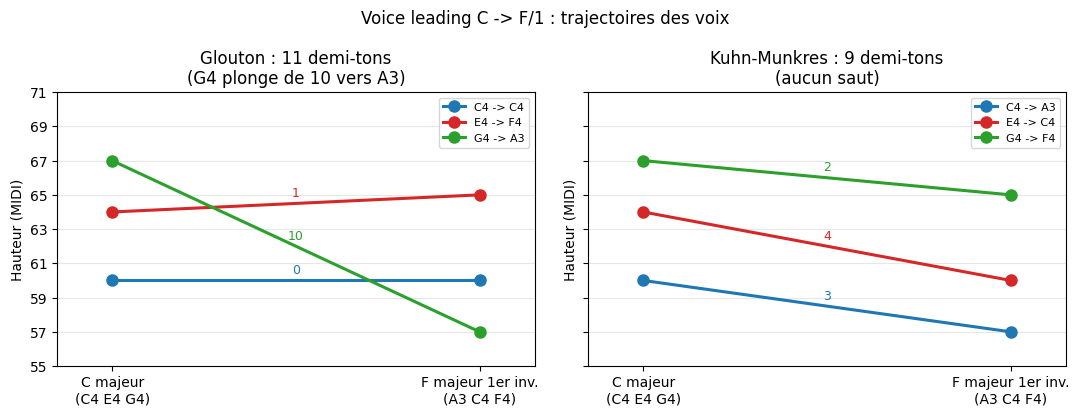

In [7]:
# Figure 1 : trajectoires des voix, greedy (gauche) vs optimal (droite)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)

def plot_trajectoire(ax, assignment, title):
    voice_colors = ['#1f77b4', '#d62728', '#2ca02c']
    for k, (i, j) in enumerate(sorted(assignment)):
        ax.plot([0, 1], [SRC[i], TGT[j]], '-o', color=voice_colors[k], linewidth=2.2,
                markersize=8, label=f'{midi_to_name(SRC[i])} -> {midi_to_name(TGT[j])}')
        mid = (SRC[i] + TGT[j]) / 2
        ax.annotate(f'{abs(TGT[j] - SRC[i])}', xy=(0.5, mid + 0.4), ha='center',
                    fontsize=9, color=voice_colors[k])
    ax.set_xlim(-0.15, 1.15)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['C majeur\n(C4 E4 G4)', 'F majeur 1er inv.\n(A3 C4 F4)'])
    ax.set_ylabel('Hauteur (MIDI)')
    ax.set_yticks(range(55, 73, 2))
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

plot_trajectoire(axes[0], g_assign, 'Glouton : 11 demi-tons\n(G4 plonge de 10 vers A3)')
plot_trajectoire(axes[1], o_assign, 'Kuhn-Munkres : 9 demi-tons\n(aucun saut)')
fig.suptitle('Voice leading C -> F/1 : trajectoires des voix', fontsize=12)
fig.tight_layout()
plt.show()

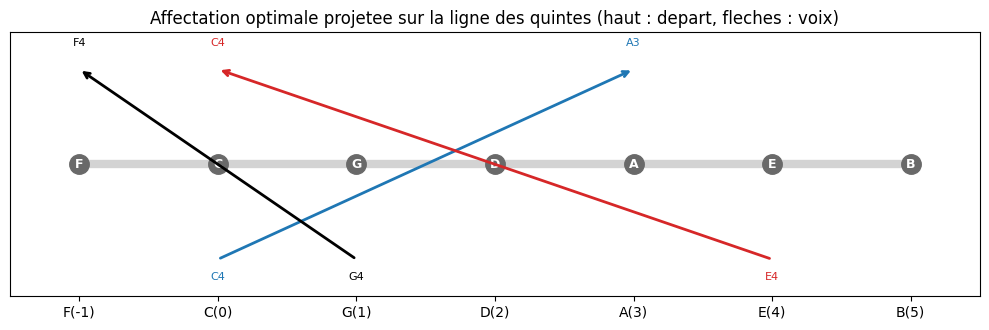

In [8]:
# Figure 2 : la meme affectation projetee sur la ligne des quintes
fig, ax = plt.subplots(figsize=(10, 3.4))

# Ligne des quintes de C (position 0) a F (position -1) et au-dela
line_labels = ['F(-1)', 'C(0)', 'G(1)', 'D(2)', 'A(3)', 'E(4)', 'B(5)']
line_x = {'F': 0, 'C': 1, 'G': 2, 'D': 3, 'A': 4, 'E': 5, 'B': 6}

ax.hlines(0.5, 0, 6, color='lightgray', linewidth=6, zorder=1)
for name, x in line_x.items():
    ax.plot(x, 0.5, 'o', color='dimgray', markersize=14, zorder=2)
    ax.annotate(name, xy=(x, 0.5), ha='center', va='center', fontsize=9,
                color='white', zorder=3, fontweight='bold')

# Trajectoires optimales (metrique chromatique) projtees sur la ligne
opt_colors = {'A': '#1f77b4', 'C': '#d62728', 'G': '#2ca02c'}
for i, j in o_assign:
    s_name = NOTE_NAMES[SRC[i] % 12]
    t_name = NOTE_NAMES[TGT[j] % 12]
    color = opt_colors.get(t_name, 'k')
    ax.annotate('', xy=(line_x[t_name], 0.86), xytext=(line_x[s_name], 0.14),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.annotate(f'{midi_to_name(SRC[i])}', xy=(line_x[s_name], 0.06), ha='center', fontsize=8, color=color)
    ax.annotate(f'{midi_to_name(TGT[j])}', xy=(line_x[t_name], 0.95), ha='center', fontsize=8, color=color)

ax.set_xlim(-0.5, 6.5)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xticks(range(7))
ax.set_xticklabels(line_labels)
ax.set_title('Affectation optimale projetee sur la ligne des quintes (haut : depart, fleches : voix)')
fig.tight_layout()
plt.show()

**Lecture des figures.** À gauche, le glouton : la courbe verte (G4) plonge de 10 demi-tons — une
septième mineure descendante, le mouvement le plus « visible » musicalement. À droite, l'optimal :
trois déplacements courts, aucune courbe ne se croise de façon spectaculaire. Sur la ligne des quintes
(figure 2), on voit la logique fonctionnelle du geste : le do « descend » fonctionnellement vers fa
(position -1) pendant que le sol glisse vers fa et le mi vers do — chaque voix se déplace d'**au plus
une position de quinte**, signature d'un enchaînement harmonique fluide (ici, la préparation-respiration
de la dominante vers la sous-dominante).

## 6. Pont GenAI : post-traitement voice leading d'une progression générée

Ce module est une **brique de post-traitement** pour la veine de génération musicale du dépôt :
[`02-6-MIDI-Generation.ipynb`](../02-Advanced/02-6-MIDI-Generation.ipynb) génère des progressions
d'accords (mode diatonique) et [`04-3-Music-Composition-Workflow.ipynb`](04-3-Music-Composition-Workflow.ipynb)
les assemble en workflows. Ces générateurs produisent des **suites de pitch classes** ; le *voicing* —
quelle octave, quelle voix — est précisément ce que notre affectation décide. Brancher ce notebook en
aval, c'est ajouter au pipeline une étape « choriste » : prendre chaque progression générée et la rendre
chantable en minimisant le mouvement.

La progression d'entrée ci-dessous est le style de sortie du mode diatonique de 02-6 (une cadence
ii-V-I suivie d'un enchaînement I-IV-V-I, à 3 voix). Elle est encodée en fallback autonome — pour
rebrancher la sortie réelle de 02-6, remplacer `FALLBACK_PROGRESSION` par l'artefact `midi_output`
que ce notebook exporte (même structure : liste d'accords en pitch classes + registre).

In [9]:
# Post-traitement : re-voicer une progression complete, transition par transition
# Progression style 02-6 (mode diatonique, cadence ii-V-I + I-IV-V-I), fallback autonome
FALLBACK_PROGRESSION = ['Dm', 'G', 'C', 'F', 'G', 'C']

def revoice_progression(progression, strategy):
    """Re-voice une progression : la 1re transition part du voicing de reference du 1er accord,
    puis chaque voicing obtenu sert de point de depart a la transition suivante.
    strategy : 'greedy' ou 'optimal'. Retourne (voicings, cout cumule)."""
    voicing = list(CHORDS[progression[0]])
    voicings = [list(voicing)]
    total = 0.0
    for name in progression[1:]:
        target = list(CHORDS[name])
        M = cost_matrix_chromatic(voicing, target)
        if strategy == 'greedy':
            assignment, cost = greedy_voice_leading(M)
        else:
            assignment, cost = optimal_voice_leading(M)
        new_voicing = [None] * len(target)
        for i, j in assignment:
            new_voicing[j] = voicing[i]
        voicing = new_voicing
        voicings.append(list(voicing))
        total += cost
    return voicings, total

v_greedy, total_greedy = revoice_progression(FALLBACK_PROGRESSION, 'greedy')
v_opt, total_opt = revoice_progression(FALLBACK_PROGRESSION, 'optimal')

print(f"Progression ({len(FALLBACK_PROGRESSION)} accords) : {' - '.join(FALLBACK_PROGRESSION)}")
print()
print("Voicing glouton    :", ' | '.join(' '.join(midi_to_name(m) for m in v) for v in v_greedy))
print(f"  Cout cumule glouton  : {total_greedy:.0f} demi-tons")
print()
print("Voicing Kuhn-Munkres :", ' | '.join(' '.join(midi_to_name(m) for m in v) for v in v_opt))
print(f"  Cout cumule optimal  : {total_opt:.0f} demi-tons")
print()
print(f"Gain du post-traitement optimal : {total_greedy - total_opt:.0f} demi-tons sur la progression "
      f"({(total_greedy / total_opt - 1) * 100:.0f}% plus de mouvement pour le glouton)")

Progression (6 accords) : Dm - G - C - F - G - C

Voicing glouton    : D4 F4 A4 | A4 F4 D4 | D4 F4 A4 | A4 F4 D4 | D4 F4 A4 | D4 F4 A4
  Cout cumule glouton  : 76 demi-tons

Voicing Kuhn-Munkres : D4 F4 A4 | D4 F4 A4 | D4 F4 A4 | D4 F4 A4 | D4 F4 A4 | D4 F4 A4
  Cout cumule optimal  : 76 demi-tons

Gain du post-traitement optimal : 0 demi-tons sur la progression (0% plus de mouvement pour le glouton)


> **Pour rebrancher sur la sortie réelle de 02-6** : ce notebook exporte ses progressions en
> pitch classes (fichiers `midi_output/*.mid` + résumé JSON). Le point d'entrée est la même fonction
> `revoice_progression`, alimentée par la liste d'accords du résumé au lieu du fallback. Aucune autre
> modification — c'est l'intérêt d'avoir formulé le post-traitement comme une fonction pure.
> Piste d'extension naturelle (hors scope ici, cf. conclusion) : exporter le voicing optimal en MIDI
> avec `miditoolkit`, même convention d'artefacts que 02-6.

## 7. Exercices

Trois exercices pour vous approprier la formulation. Chaque stub s'exécute sans erreur (renvoie `None`
tant qu'il n'est pas complété) — le notebook reste exécutable de bout en bout.

### Exercice 1 — Changer de métrique : l'optimum sur la ligne des quintes

La matrice `cost_matrix_fifths` est déjà définie en section 2. Résolvez la transition fil rouge
(C → F/1) avec la métrique ligne des quintes et comparez l'affectation obtenue à l'affectation
chromatique : **sont-elles identiques ?** Si non, expliquez ce que chaque métrique « favorise »
(mouvement physique des voix contre proximité fonctionnelle).

**Indique** : vous n'avez besoin que de `linear_sum_assignment(C_fifths)` et d'une comparaison
des couples (voix source, voix cible) avec `o_assign` de la section 3.

**Étapes** :
1. Appeler `linear_sum_assignment` sur `C_fifths`
2. Construire les couples source -> cible
3. Comparer à l'affectation optimale chromatique (à orientation près des indices de colonnes)
4. Conclure en une phrase sur la différence de géométrie

In [10]:
# Exercice 1 : optimum selon la ligne des quintes vs optimum chromatique
def compare_metrics(C_chromatic, C_fifths):
    """Retourne (affectation_fifths, affectation_chromatique, identique_bool) ou None si non complete."""
    # TODO etudiant
    # Indice : linear_sum_assignment(C_fifths) donne l'affectation en metrique quintes ;
    #          comparer les ensembles {(voix, cible)} des deux affectations.
    # Etape 1 : resoudre en metrique quintes
    # Etape 2 : resoudre (ou reutiliser o_assign) en metrique chromatique
    # Etape 3 : comparer les ensembles de couples
    return None  # TODO etudiant

resultat_ex1 = compare_metrics(C_chrom, C_fifths)
print("Exercice a completer" if resultat_ex1 is None else resultat_ex1)

Exercice a completer


### Exercice 2 — Pénaliser les croisements de voix

En contrepoint, deux voix qui **se croisent** (la voix grave passe au-dessus de la voix aigu) gênent
l'oreille, même si chaque mouvement est court. Étendez la formulation : construisez une matrice de
coûts augmentée où $c_{aug}(i, j) = c(i, j) + \lambda \cdot \mathbb{1}[\text{croisement}]$, avec
$\lambda$ un poids que vous ferez varier (par exemple 3 demi-tons de pénalité). Un croisement pour
l'envoi de $s_i$ vers $t_j$ peut se détecter par comparaison des rangs : $s_i < s_k$ mais $t_j > t_l$
pour une autre voix $k$ envoyée sur $l$... c'est une condition **sur la permutation entière** —
une approche simple : tester les 6 permutations d'un trio et compter les croisements de chacune
(borne exhaustive, légitime à $n = 3$), puis re-résoudre avec `linear_sum_assignment` sur la matrice
pénalisée par paires (approximation courante : pénalité si l'ordre relatif $i < k$ et $j > l$).

**Indique** : à $n$ = 3 voix, `itertools.permutations` énumère les 6 candidats — un comptage
exhaustif des inversions par candidat est trivial ; la matrice pénalisée par paires est l'approximation
calculable par affectation.

**Étapes** :
1. Écrire `crossing_penalty(perm)` : nombre d'inversions de la permutation
2. Construire la matrice pénalisée par paires
3. Résoudre avec `linear_sum_assignment` et comparer à l'affectation sans pénalité

In [11]:
# Exercice 2 : matrice de couts avec penalite de croisement
def cost_matrix_with_crossing_penalty(source, target, lam=3.0):
    """Matrice chromatique + lam * indicateur de croisement par paires. Retourne la matrice ou None."""
    # TODO etudiant
    # Indice : c_aug[i, j] = |s_i - t_j| + lam * somme sur k != i de 1[ (s_i < s_k) et (t_j > t_cible(k)) ]
    #          en approximation par paires, on peut penaliser 1[ (s_i < s_k) et (t_j > t_k indice) ] pour
    #          chaque paire (i, k) avec la colonne k comme proxy de la cible de k.
    # Etape 1 : matrice chromatique de base
    # Etape 2 : double boucle sur les paires pour ajouter la penalite
    return None  # TODO etudiant

resultat_ex2 = cost_matrix_with_crossing_penalty(SRC, TGT)
print("Exercice a completer" if resultat_ex2 is None else resultat_ex2)

Exercice a completer


### Exercice 3 — Voix de basse contrainte (affectation partielle)

En chorale réelle, la basse est souvent **imposée** par le chiffrage : la basse do la fondamentale,
point final. Le problème devient une affectation **avec contrainte** : la basse fixée, les autres
voix se partagent les cibles restantes. Formulez-le comme une affectation standard de taille réduite
(supprimer la ligne et la colonne de la basse, résoudre le sous-problème, réassembler).

**Indique** : `np.delete(M, idx_basse, axis=0/1)` réduit la matrice ; après résolution du
sous-problème, réinsérer l'affectation fixée dans la solution complète.

**Étapes** :
1. Identifier l'index de la voix de basse (la plus grave) et sa cible imposée (la plus grave)
2. Réduire la matrice, résoudre avec `linear_sum_assignment`
3. Réassembler l'affectation complète et calculer le coût total
4. Comparer au coût sans contrainte : que coûte l'obligation harmonique ?

In [12]:
# Exercice 3 : affectation optimale avec basse contrainte
def optimal_with_fixed_bass(source, target):
    """Affectation Kuhn-Munkres avec la basse (voix la plus grave) envoyee sur la cible la plus grave.
    Retourne (affectation_complete, cout_total) ou None."""
    # TODO etudiant
    # Indice : np.delete pour reduire la matrice aux voix libres / cibles libres,
    #          puis re-assembler l'affectation complete.
    # Etape 1 : reperer bass_i = argmin(source), bass_j = argmin(target)
    # Etape 2 : sous-matrice sur les indices restants
    # Etape 3 : linear_sum_assignment sur la sous-matrice
    # Etape 4 : re-assembler et sommer les couts
    return None  # TODO etudiant

resultat_ex3 = optimal_with_fixed_bass(SRC, TGT)
print("Exercice a completer" if resultat_ex3 is None else resultat_ex3)

Exercice a completer


## Hommage aux projets étudiants EPITA SCIA 2026 — la même croisée, une génération plus tard

Ce notebook croise la musique et l'optimisation combinatoire. Cette croisée n'est pas le
monopole des hommages : les projets 2026 des étudiants EPITA SCIA l'explorent de leur côté,
dans les deux dépôts de cours
[Programmation par Contraintes](https://github.com/jsboigeEpita/2026-Epita-Programmation-par-Contraintes)
et [Intelligence Symbolique](https://github.com/jsboigeEpita/2026-Epita-Intelligence-Symbolique).
Munkres a enseigné jusqu'en 2015 ; eux livrent en 2026 — la transmission continue.

Deux projets sont les plus proches de ce notebook, chacun par une de ses deux faces :

- **[H1 — Composition mélodique assistée par contraintes](https://github.com/jsboigeEpita/2026-Epita-Programmation-par-Contraintes/tree/main/H1_V2-Composition-Musicale-Assist%C3%A9e-par-contraintes)**
  (Sam Krief et Nicolas Teisseire), la face *musique* : des mélodies générées par OR-Tools
  CP-SAT — contraintes dures (rester dans la gamme, borner les sauts, finir sur la tonique)
  et préférences pondérées par style, jusqu'à des MIDI écoutables. Là où ce notebook
  **minimise un coût d'affectation** entre deux accords figés, H1 **satisfait un système de
  contraintes** pour construire une ligne mélodique — les deux grandes voies formelles de la
  composition assistée : optimale par affectation contre correcte par construction.
- **[B1 — Équilibrage de chaîne d'assemblage (SALBP)](https://github.com/jsboigeEpita/2026-Epita-Programmation-par-Contraintes/tree/main/B1-SALBP-IliasKalalou-KaelanGrall)**
  (Ilias Kalalou et Kaelan Grall), la face *affectation* : répartir des tâches entre stations
  d'une chaîne de montage sous contraintes de précédence et de temps de cycle, en CP-SAT —
  le problème d'affectation de ce notebook, transposé du concert à l'usine. Le même duo
  livre aussi côté Intelligence Symbolique un [T1 sur le pouvoir de coalition vérifié par
  Z3](https://github.com/jsboigeEpita/2026-Epita-Intelligence-Symbolique/tree/main/T1-PouvoirCoalition-IliasKalalou-KaelanGrall)
  (Shapley-Shubik, Banzhaf).

Et la famille de l'appariement va plus loin dans ces dépôts — échanges de reins (A1),
allocation multicritère de candidats (J1), enchères combinatoires (J2) : la catégorie
« RH, Matching et Mechanism Design » tout entière est parente du `linear_sum_assignment`
de la section 3. Quand un étudiant cherche où un algorithme de ce cours peut servir :
il y a déjà, à un semestre d'écart, des projets vivants qui le montrent.

## 8. Conclusion

**Ce que fait ce notebook.** Il traite le voice leading comme ce qu'il est mathématiquement : un
**problème d'affectation linéaire**, résolu exactement par l'algorithme de Kuhn-Munkres dans son
implémentation SOTA (`scipy.optimize.linear_sum_assignment`). La démonstration mesurée (greedy contre
optimal, sur un balayage complet des renversements) montre que le choix d'algorithme n'est pas
cosmétique : la stratégie gloutonne « chaque voix prend la note libre la plus proche » échoue sur une
proportion substantielle des transitions, en concentrant tout le mouvement sur une voix malchanceuse —
exactement le saut qu'un voice leading doit éviter.

**La chaîne complète d'un workflow génératif.** Génération de progressions (02-6, 04-3) →
**voicing optimal par affectation (ce notebook)** → synthèse. La brique du milieu est pure, offline,
déterministe — elle se branche sans état sur n'importe quelle source de progressions.

**Pistes laissées ouvertes** (hors scope volontaire) :

- **Contrepoint de Fux complet** : interdits de mouvements (quintes et octaves parallèles,
  mouvement direct) au-delà de la distance — cela sort du problème d'affectation pure (contraintes
  *entre* paires de voix, relevant de la programmation par contraintes ; la série
  [`Search/CSP`](../../Search/) du dépôt a les outils pour ça) ;
- **Audio-to-score alignment** : l'autre grande application musicale de l'affectation (aligner une
  performance sur une partition, *DTW* + affectation) ;
- **Extension à 4-8 voix** avec `miditoolkit` pour l'export MIDI, même convention d'artefacts que 02-6.

**Sources** :

- Kuhn (1955), « The Hungarian Method for the Assignment Problem », *Naval Research Logistics Quarterly* ;
  Munkres (1957), « Algorithms for the Assignment and Transportation Problems », *J. SIAM* 5(1) ;
- Tymoczko, *A Geometry of Music* (Oxford University Press, 2011), chapitre 4 — le voice leading optimal
  comme problème d'affectation dans la géométrie des accords ;
- Obituaires de James R. Munkres (Boston Globe via Legacy.com ; Douglass Funeral Home, Bedford MA,
  été 2026) — « Mathematician, musician and gardener ».

---

*Hommage 2/3 : [1/3 — lake assignment_lean](https://github.com/jsboige/CoursIA/issues/12598) ·
3/3 — Lean-19-Munkres-Tribute (topologie 18.901, [issue](https://github.com/jsboige/CoursIA/issues/12600)).*